# EDA собственной API-выборки League of Legends

В этом ноутбуке анализируем данные, которые собрали через Riot API.

Цель этапа:

- проверить качество API-выборки;
- понять распределение по лигам, ролям и чемпионам;
- сравнить победителей и проигравших;
- подготовить агрегированные таблицы для будущего дашборда.

Источник данных: `data/api/matches_api_enriched.csv`.


## 0. Установка библиотеки для графиков

Если `matplotlib` уже установлен в выбранном kernel, эта ячейка ничего существенного не изменит. Если библиотеки нет, она установит ее в текущее окружение ноутбука.


In [1]:
%pip install -q matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\fiery\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Импорт библиотек и настройки

Используем `pandas` для таблиц и `matplotlib` для простых графиков.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.3f}".format)


PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent


DATA_PATH = PROJECT_ROOT / "data" / "api" / "matches_api_enriched.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "api_eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Загрузка API-данных

Одна строка в таблице — один участник матча. Один матч должен давать 10 строк.


In [3]:
api_df = pd.read_csv(DATA_PATH)

print("Размер таблицы:", api_df.shape)
print("Уникальных матчей:", api_df["match_id"].nunique())
print("Уникальных игроков:", api_df["puuid"].nunique())
print("Уникальных чемпионов:", api_df["champion_name"].nunique())

api_df.head()


Размер таблицы: (3570, 64)
Уникальных матчей: 357
Уникальных игроков: 1707
Уникальных чемпионов: 171


,match_id,source_puuid,source_tier,game_creation,game_start_timestamp,game_end_timestamp,game_duration_sec,game_mode,game_type,game_version,map_id,platform_id,queue_id,participant_id,puuid,summoner_id,summoner_name,riot_id_game_name,riot_id_tagline,summoner_level,champion_id,champion_name,team_id,win,team_position,individual_position,lane,role,kills,deaths,assists,gold_earned,gold_spent,total_damage_dealt_to_champions,total_damage_taken,damage_self_mitigated,total_minions_killed,neutral_minions_killed,vision_score,wards_placed,wards_killed,detector_wards_placed,dragon_kills,baron_kills,turret_kills,double_kills,triple_kills,quadra_kills,penta_kills,kda_challenge,kill_participation,item0,item1,item2,item3,item4,item5,item6,collected_at_utc,kda,game_duration_min,damage_per_min,gold_per_min,vision_per_min
0,EUW1_7875127465,kUdJh-6XcgbS1PnyMw8P0OkfxgDWEa26wDlQA8N9CKIB8N...,challenger,1780499476522,1780499487319,1780500792651,1305,CLASSIC,MATCHED_GAME,16.11.782.9736,11,EUW1,420,1,bVsa8mfzUUhIQ5Y8ZcCY-Gn2wXZ_fMRdzrNwslEhELeJP3...,t8tExSPNiSG-56y-Xc_q3_jAUkU-7v2X7t9Yeh3fnfgd9y4,NaN,TheRoyalKanin,EUW,1258,58,Renekton,100,False,TOP,TOP,JUNGLE,NONE,2,3,1,7692,7025,8585,27470,18023,184,0,21,7,2,1,0,0,0,0,0,0,0,1.000,0.167,1054,1028,3111,6631,1028,1037,3340,2026-06-03T16:07:47+00:00,1.000,21.750,394.713,353.655,0.966
1,EUW1_7875127465,kUdJh-6XcgbS1PnyMw8P0OkfxgDWEa26wDlQA8N9CKIB8N...,challenger,1780499476522,1780499487319,1780500792651,1305,CLASSIC,MATCHED_GAME,16.11.782.9736,11,EUW1,420,2,dx95lhwSFR_6Z6tIZ-4hT2cJAQacOVCy1QkSPyKpLIDV_H...,uAfL8ZENMHJIYJucA5E43GxcFax0DXAABZzK2bLPuqbut-...,NaN,TryhardEkko,TWTV,154,245,Ekko,100,False,JUNGLE,JUNGLE,JUNGLE,NONE,3,6,5,8371,7800,13364,22618,14222,8,133,18,3,5,0,0,0,0,0,0,0,0,1.333,0.444,3115,1082,3100,1058,0,2422,3364,2026-06-03T16:07:47+00:00,1.333,21.750,614.437,384.874,0.828
2,EUW1_7875127465,kUdJh-6XcgbS1PnyMw8P0OkfxgDWEa26wDlQA8N9CKIB8N...,challenger,1780499476522,1780499487319,1780500792651,1305,CLASSIC,MATCHED_GAME,16.11.782.9736,11,EUW1,420,3,QvKDaxIaW3M22FDi3laEO4UC16zVAQjAs4X8VO_csOiY_3...,i6rW2aOeSmSZidUFrzYofUOQgjOC_CN5rZM7effMU-9M9GYQ,NaN,azur et asmar,paix,424,136,AurelionSol,100,False,MIDDLE,MIDDLE,MIDDLE,SOLO,8,7,3,8685,8175,11393,21461,15206,118,0,13,5,2,1,0,0,0,1,0,0,0,1.571,0.611,3116,3173,1082,6653,1056,1052,3364,2026-06-03T16:07:47+00:00,1.571,21.750,523.816,399.310,0.598
3,EUW1_7875127465,kUdJh-6XcgbS1PnyMw8P0OkfxgDWEa26wDlQA8N9CKIB8N...,challenger,1780499476522,1780499487319,1780500792651,1305,CLASSIC,MATCHED_GAME,16.11.782.9736,11,EUW1,420,4,mzdMMvsch-WVRJhKTRz1JXj4FpxGQuihniUREjPJRRZHv-...,vPPDP62TX4txR5YMkYktzlShI9tdc7S0IDsRLHY0NSdKzVE,NaN,2809200320062000,2809,925,119,Draven,100,False,BOTTOM,BOTTOM,BOTTOM,SOLO,4,8,5,10152,9950,13150,14827,6878,161,4,13,7,2,0,0,0,0,0,0,0,0,1.125,0.500,2523,6697,1055,3035,6670,0,3363,2026-06-03T16:07:47+00:00,1.125,21.750,604.598,466.759,0.598
4,EUW1_7875127465,kUdJh-6XcgbS1PnyMw8P0OkfxgDWEa26wDlQA8N9CKIB8N...,challenger,1780499476522,1780499487319,1780500792651,1305,CLASSIC,MATCHED_GAME,16.11.782.9736,11,EUW1,420,5,XJDzfs5i32XRnays3RnZfHOF-KDacttRsVugqRbz1sdKBD...,1xgKUqyUjdxhL6nPgl4kdTwp8pI-ZI7TxNGI-edfDjG8eZDP,NaN,TF AON,TOTO,367,43,Karma,100,False,UTILITY,UTILITY,JUNGLE,NONE,1,5,9,6039,5380,5107,12654,6630,44,0,73,27,12,4,0,0,0,0,0,0,0,2.000,0.556,3869,3107,2031,3158,4642,1028,3364,2026-06-03T16:07:47+00:00,2.000,21.750,234.805,277.655,3.356


## 3. Контроль качества

Проверяем, что каждый матч представлен ровно 10 участниками. Это ключевая проверка после распрямления JSON из Riot API.


In [4]:
participants_per_match = api_df["match_id"].value_counts()
participants_per_match.value_counts().sort_index()


count
10    357
Name: count, dtype: int64

In [5]:
important_columns = [
    "match_id",
    "puuid",
    "source_tier",
    "champion_name",
    "team_position",
    "win",
    "kills",
    "deaths",
    "assists",
    "kda",
    "damage_per_min",
    "gold_per_min",
    "vision_per_min",
]

missing_values = (
    api_df[important_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values


match_id          0
puuid             0
source_tier       0
champion_name     0
team_position     0
win               0
kills             0
deaths            0
assists           0
kda               0
damage_per_min    0
gold_per_min      0
vision_per_min    0
dtype: int64

### Вывод по качеству

API-выборка прошла базовую проверку качества: каждый матч представлен ровно 10 строками участников. Это значит, что вложенный JSON из Riot API был корректно преобразован в табличный формат.

Критичные для анализа поля (`match_id`, `puuid`, `champion_name`, `team_position`, игровые метрики и результат матча) можно использовать для первичного EDA. Если в отдельных дополнительных колонках есть пропуски, это не мешает текущему анализу, потому что основные расчетные показатели уже заполнены.


## 4. Распределение по лигам

`source_tier` показывает, через какую лигу мы нашли матч. Это не обязательно ранг каждого участника, но это хороший признак источника сбора.


In [6]:
tier_overview = (
    api_df
    .groupby("source_tier")
    .agg(
        rows=("match_id", "size"),
        matches=("match_id", "nunique"),
        players=("puuid", "nunique"),
        champions=("champion_name", "nunique"),
        avg_game_duration_min=("game_duration_min", "mean"),
    )
    .reset_index()
    .sort_values("matches", ascending=False)
)

tier_overview


,source_tier,rows,matches,players,champions,avg_game_duration_min
1,grandmaster,1230,123,848,160,26.535
0,challenger,1200,120,599,161,25.969
2,master,1140,114,853,166,26.900


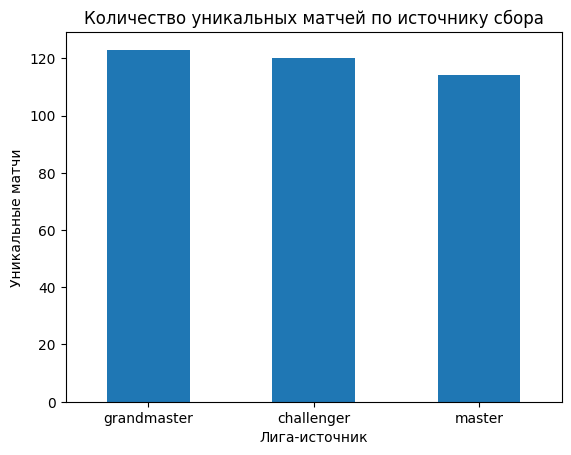

In [7]:
tier_overview.plot(
    x="source_tier",
    y="matches",
    kind="bar",
    legend=False,
    title="Количество уникальных матчей по источнику сбора",
)
plt.xlabel("Лига-источник")
plt.ylabel("Уникальные матчи")
plt.xticks(rotation=0)
plt.show()


### Вывод по распределению лиг

Выборка получилась достаточно сбалансированной по источнику сбора: матчи были найдены через игроков Challenger, Grandmaster и Master. `source_tier` показывает не ранг каждого участника матча, а лигу стартового игрока, через которого матч попал в выборку.

Это важно для интерпретации: корректнее говорить “матчи, найденные через верхние лиги”, а не “все участники этих матчей имеют такой-то ранг”.


## 5. Метрики по ролям

Сравниваем позиции по KDA, урону, золоту и обзору в минуту.


In [8]:
role_stats = (
    api_df
    .groupby("team_position")
    .agg(
        rows=("match_id", "size"),
        matches=("match_id", "nunique"),
        players=("puuid", "nunique"),
        avg_kda=("kda", "mean"),
        avg_damage_per_min=("damage_per_min", "mean"),
        avg_gold_per_min=("gold_per_min", "mean"),
        avg_vision_per_min=("vision_per_min", "mean"),
    )
    .reset_index()
    .sort_values("avg_damage_per_min", ascending=False)
)

role_stats


,team_position,rows,matches,players,avg_kda,avg_damage_per_min,avg_gold_per_min,avg_vision_per_min
0,BOTTOM,714,357,411,3.547,881.256,499.620,0.691
2,MIDDLE,714,357,408,3.567,838.793,437.050,0.716
3,TOP,714,357,488,2.770,763.429,412.876,0.818
1,JUNGLE,714,357,412,4.521,692.334,462.724,0.974
4,UTILITY,714,357,472,4.226,387.820,313.931,2.872


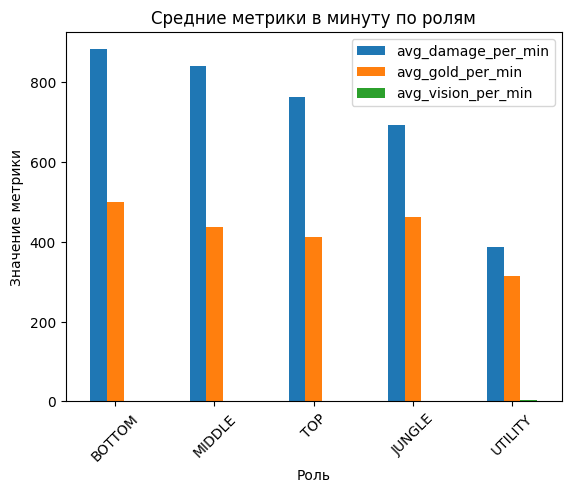

In [9]:
role_stats.plot(
    x="team_position",
    y=["avg_damage_per_min", "avg_gold_per_min", "avg_vision_per_min"],
    kind="bar",
    title="Средние метрики в минуту по ролям",
)
plt.xlabel("Роль")
plt.ylabel("Значение метрики")
plt.xticks(rotation=45)
plt.show()


### Вывод по ролям

Распределение по ролям сбалансировано: в каждом матче есть по два игрока каждой позиции, поэтому сравнение ролей корректно по объему строк.

По API-выборке `BOTTOM` показывает самый высокий средний урон в минуту и золото в минуту. `UTILITY` ожидаемо лидирует по vision score в минуту, потому что роль поддержки больше связана с обзором карты. `JUNGLE` показывает высокий средний KDA, что может быть связано с участием в убийствах на разных линиях и меньшим количеством прямых дуэлей на линии.


## 6. Чемпионы: популярность, winrate и средние метрики

Для winrate важен минимальный порог игр. Иначе чемпион с 1 победой из 1 игры будет выглядеть как лучший.


In [10]:
MIN_CHAMPION_GAMES = 10

champion_stats = (
    api_df
    .groupby("champion_name")
    .agg(
        games=("match_id", "nunique"),
        wins=("win", "sum"),
        winrate=("win", "mean"),
        avg_kda=("kda", "mean"),
        avg_damage_per_min=("damage_per_min", "mean"),
        avg_gold_per_min=("gold_per_min", "mean"),
        avg_vision_per_min=("vision_per_min", "mean"),
    )
    .reset_index()
)

champion_stats_filtered = (
    champion_stats
    .query("games >= @MIN_CHAMPION_GAMES")
    .sort_values(["winrate", "games"], ascending=[False, False])
)

champion_stats_filtered.head(20)


,champion_name,games,wins,winrate,avg_kda,avg_damage_per_min,avg_gold_per_min,avg_vision_per_min
53,Jinx,24,18,0.750,4.273,855.987,522.561,0.660
149,Vi,22,16,0.727,5.147,653.049,459.694,1.110
77,Malzahar,10,7,0.700,3.442,773.367,472.582,0.692
15,Blitzcrank,13,9,0.692,7.216,336.931,305.782,2.868
170,Zyra,16,11,0.688,3.909,925.433,432.405,1.321
165,Zed,41,28,0.683,5.127,926.246,496.032,0.748
0,Aatrox,33,22,0.667,5.031,734.885,427.899,0.978
132,Taliyah,27,18,0.667,4.706,838.348,452.216,0.965
94,Nunu,18,12,0.667,7.074,513.456,407.672,1.067
126,Sona,12,8,0.667,3.915,391.221,319.057,2.851


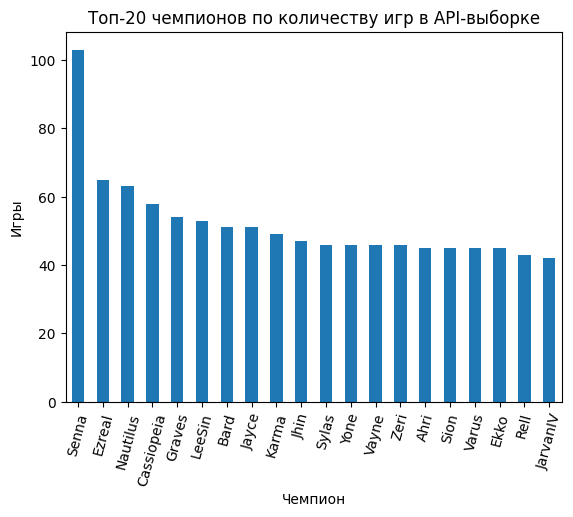

In [11]:
popular_champions = (
    champion_stats
    .sort_values("games", ascending=False)
    .head(20)
)

popular_champions.plot(
    x="champion_name",
    y="games",
    kind="bar",
    legend=False,
    title="Топ-20 чемпионов по количеству игр в API-выборке",
)
plt.xlabel("Чемпион")
plt.ylabel("Игры")
plt.xticks(rotation=75)
plt.show()


### Вывод по чемпионам

Для анализа чемпионов используется минимальный порог игр (`MIN_CHAMPION_GAMES`), чтобы не делать выводы по слишком маленькой базе. В черновом EDA стоит порог 10 игр, но для финальных выводов лучше протестировать более строгий порог: 20 или 30 игр.

Таблица с популярностью чемпионов полезна отдельно от winrate: популярные чемпионы показывают мету и предпочтения игроков, а winrate помогает искать наиболее успешные пики внутри выборки.


## 7. Победители vs проигравшие

Сравниваем игровые метрики победившей и проигравшей стороны. Это один из самых понятных аналитических срезов для дашборда.


In [12]:
winner_loser_stats = (
    api_df
    .groupby("win")
    .agg(
        rows=("match_id", "size"),
        avg_kda=("kda", "mean"),
        avg_damage_per_min=("damage_per_min", "mean"),
        avg_gold_per_min=("gold_per_min", "mean"),
        avg_vision_per_min=("vision_per_min", "mean"),
        avg_kills=("kills", "mean"),
        avg_deaths=("deaths", "mean"),
        avg_assists=("assists", "mean"),
    )
    .reset_index()
)

winner_loser_stats["result"] = winner_loser_stats["win"].map({False: "loss", True: "win"})
winner_loser_stats


,win,rows,avg_kda,avg_damage_per_min,avg_gold_per_min,avg_vision_per_min,avg_kills,avg_deaths,avg_assists,result
0,False,1785,1.656,644.883,389.330,1.172,4.064,6.580,5.969,loss
1,True,1785,5.796,780.570,461.150,1.257,6.568,4.082,10.022,win


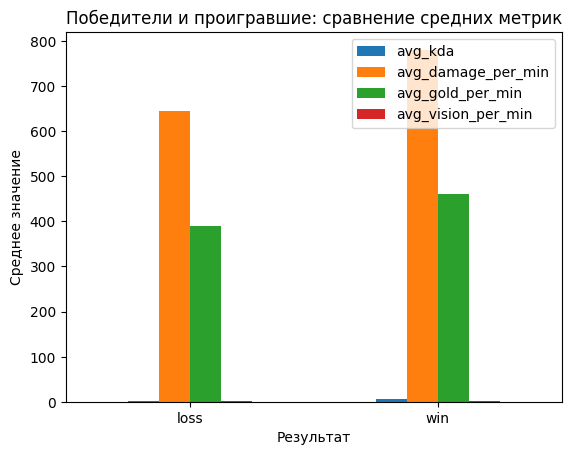

In [13]:
winner_loser_stats.plot(
    x="result",
    y=["avg_kda", "avg_damage_per_min", "avg_gold_per_min", "avg_vision_per_min"],
    kind="bar",
    title="Победители и проигравшие: сравнение средних метрик",
)
plt.xlabel("Результат")
plt.ylabel("Среднее значение")
plt.xticks(rotation=0)
plt.show()


### Вывод по победителям и проигравшим

Сравнение победителей и проигравших дает один из самых понятных аналитических срезов. В API-выборке победители имеют заметно более высокие KDA, урон в минуту, золото в минуту, среднее число убийств и ассистов.

Этот блок хорошо подходит для будущего дашборда: можно показать, какие игровые показатели сильнее всего отличаются между победой и поражением.


## 8. Лиги и роли вместе

Этот срез помогает понять, одинаково ли ведут себя роли в разных лигах-источниках.


In [14]:
tier_role_stats = (
    api_df
    .groupby(["source_tier", "team_position"])
    .agg(
        rows=("match_id", "size"),
        matches=("match_id", "nunique"),
        avg_kda=("kda", "mean"),
        avg_damage_per_min=("damage_per_min", "mean"),
        avg_gold_per_min=("gold_per_min", "mean"),
        avg_vision_per_min=("vision_per_min", "mean"),
    )
    .reset_index()
    .sort_values(["source_tier", "team_position"])
)

tier_role_stats


,source_tier,team_position,rows,matches,avg_kda,avg_damage_per_min,avg_gold_per_min,avg_vision_per_min
0,challenger,BOTTOM,240,120,3.699,855.690,496.692,0.732
1,challenger,JUNGLE,240,120,4.759,664.172,460.305,1.018
2,challenger,MIDDLE,240,120,3.702,808.092,439.564,0.759
3,challenger,TOP,240,120,2.680,729.496,407.802,0.851
4,challenger,UTILITY,240,120,4.658,377.438,310.392,2.992
5,grandmaster,BOTTOM,246,123,3.456,890.868,504.235,0.674
6,grandmaster,JUNGLE,246,123,4.278,708.908,463.796,0.942
7,grandmaster,MIDDLE,246,123,3.535,857.388,435.251,0.705
8,grandmaster,TOP,246,123,2.798,756.627,412.210,0.814
9,grandmaster,UTILITY,246,123,3.979,410.433,318.101,2.784


### Вывод по связке лиги и роли

Срез `source_tier + team_position` нужен, чтобы смотреть роли не только в среднем по всей выборке, но и внутри каждого источника сбора. Это помогает заметить, например, сохраняется ли лидерство BOTTOM по урону в разных лигах.

Для финальных выводов этот срез лучше использовать осторожно: после разделения на лиги и роли размер каждой группы становится меньше.


## 9. Сохранение агрегатов

Эти таблицы можно использовать дальше для SQL-слоя, презентации выводов или дашборда.


In [ ]:
tier_overview.to_csv(OUTPUT_DIR / "api_tier_overview.csv", index=False)
role_stats.to_csv(OUTPUT_DIR / "api_role_stats.csv", index=False)
champion_stats.to_csv(OUTPUT_DIR / "api_champion_stats.csv", index=False)
champion_stats_filtered.to_csv(OUTPUT_DIR / "api_champion_stats_filtered.csv", index=False)
winner_loser_stats.to_csv(OUTPUT_DIR / "api_winner_loser_stats.csv", index=False)
tier_role_stats.to_csv(OUTPUT_DIR / "api_tier_role_stats.csv", index=False)

print("Агрегаты сохранены в:", OUTPUT_DIR)


## 10. Итоговые выводы по API-EDA

- Собственная API-выборка состоит из 357 матчей и 3570 строк участников.
- Структура данных корректна: каждый матч представлен ровно 10 участниками.
- Выборка достаточно сбалансирована по источнику сбора: Challenger, Grandmaster и Master.
- По ролям видно ожидаемое разделение: BOTTOM лидирует по урону и золоту в минуту, UTILITY — по vision score.
- Победители заметно превосходят проигравших по KDA, урону, золоту, убийствам и ассистам.
- Для анализа чемпионов нужен порог по количеству игр: черновой порог 10 игр подходит для EDA, но для финальных выводов лучше проверить 20 или 30 игр.

Эти результаты можно использовать как отдельный API-блок проекта и как основу для будущих визуализаций в дашборде.


## 11. Что делаем дальше

Следующий этап — сравнить API-выборку с большим Kaggle-датасетом и решить, какие таблицы пойдут в финальный дашборд.

Кандидаты для дашборда:

- метрики по ролям;
- топ чемпионов по популярности;
- winrate чемпионов с порогом по числу игр;
- сравнение победителей и проигравших;
- фильтр по роли или чемпиону.
